In [72]:
import os
import cv2
import matplotlib.pyplot as plt
import random

In [73]:
import os
import cv2
import matplotlib.pyplot as plt

def preprocess_image_to_160x160(img_path):
    """
    Loads an image, removes plot-like borders, and returns a 160x160
    center-cropped RGB image.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at: {img_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_cropped = img[4:-47, 94:]

    h, w, _ = img_cropped.shape
    crop_size = 162
    start_y = (h - crop_size) // 2
    start_x = (w - crop_size) // 2
    cropped_162 = img_cropped[start_y:start_y + crop_size, start_x:start_x + crop_size]
    final_crop = cropped_162[1:-1, 1:-1]

    return final_crop  

def process_and_save_all_images(source_folder, dest_folder):
    """
    Applies preprocessing to all images in a folder and saves to a new destination.
    """
    os.makedirs(dest_folder, exist_ok=True)

    for filename in os.listdir(source_folder):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(source_folder, filename)
            try:
                processed_img = preprocess_image_to_160x160(img_path)
                dest_path = os.path.join(dest_folder, filename)
                cv2.imwrite(dest_path, processed_img)  
                print(f"Saved: {dest_path}")
            except Exception as e:
                print(f"Error with {filename}: {e}")


In [74]:
# Process both folders
process_and_save_all_images("benign", "benign_preprocessed")
process_and_save_all_images("jamming", "jamming_preprocessed")


Saved: benign_preprocessed/20250412_192.png
Saved: benign_preprocessed/20250412_99.png
Saved: benign_preprocessed/20250412_55.png
Saved: benign_preprocessed/20250412_148.png
Saved: benign_preprocessed/20250412_113.png
Saved: benign_preprocessed/20250412_62.png
Saved: benign_preprocessed/20250412_53.png
Saved: benign_preprocessed/20250412_51.png
Saved: benign_preprocessed/20250412_119.png
Saved: benign_preprocessed/20250412_9.png
Saved: benign_preprocessed/20250412_63.png
Saved: benign_preprocessed/20250412_177.png
Saved: benign_preprocessed/20250412_124.png
Saved: benign_preprocessed/20250412_156.png
Saved: benign_preprocessed/20250412_15.png
Saved: benign_preprocessed/20250412_98.png
Saved: benign_preprocessed/20250412_199.png
Saved: benign_preprocessed/20250412_32.png
Saved: benign_preprocessed/20250412_44.png
Saved: benign_preprocessed/20250412_73.png
Saved: benign_preprocessed/20250412_187.png
Saved: benign_preprocessed/20250412_158.png
Saved: benign_preprocessed/20250412_37.png
Sa

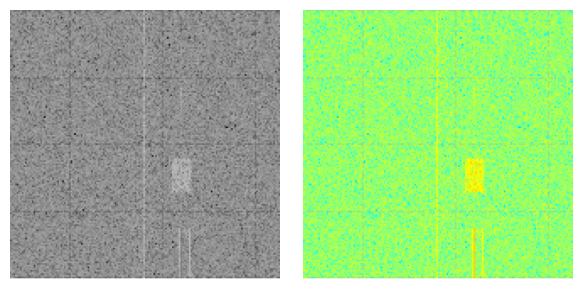

In [75]:

# Load image
img_path = os.path.join("jamming_preprocessed", "20250412_120.png")
img = cv2.imread(img_path)

# Convert to RGB and Grayscale
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Plot side by side
plt.figure(figsize=(6, 3))

# Grayscale
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

# RGB
plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()
